# 1. Introduction

Project ini bertujuan untuk membangun model prediksi harga emas yang dapat membantu memahami pergerakan harga emas berdasarkan data historis. Harga emas sering mengalami perubahan karena dipengaruhi oleh berbagai faktor ekonomi dan pasar, sehingga analisis berbasis time series diperlukan untuk melihat pola, tren, dan kemungkinan pergerakan harga di masa depan.

Dalam project ini, data historis harga emas digunakan untuk melakukan eksplorasi data, preprocessing, pengujian stasioneritas, serta pemodelan menggunakan pendekatan time series seperti ARIMA, SARIMA, dan Prophet. Performa setiap model dibandingkan menggunakan metrik evaluasi seperti MAE, RMSE, MAPE, dan R-squared untuk menentukan model terbaik. Dengan pendekatan ini, hasil prediksi dapat memberikan gambaran yang lebih terukur mengenai harga emas, sehingga dapat mendukung proses analisis dan pengambilan keputusan dalam konteks trading atau investasi.


# 2. Import Library

In [ ]:
import os  
import itertools  
import warnings  
from datetime import datetime  
import joblib 
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt  
import statsmodels.api as sm  
from sklearn.metrics import mean_squared_error  
from sklearn.metrics import mean_absolute_error  
from sklearn.metrics import mean_absolute_percentage_error  
from sklearn.metrics import r2_score  
from statsmodels.tsa.stattools import adfuller  
from statsmodels.tsa.seasonal import seasonal_decompose  
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf  
from statsmodels.tsa.arima.model import ARIMA  
from statsmodels.tsa.statespace.sarimax import SARIMAX  
from prophet import Prophet  
warnings.filterwarnings("ignore")
print("All libraries imported successfully.")


All libraries imported successfully.


# 3. Data Loading

In [61]:
df_raw = pd.read_csv('profin_clean (2).csv')
df_raw.head(10)

,date,close,high,low,open,volume
0,2003-01-02,346.100006,346.100006,346.100006,346.100006,3
1,2003-01-03,351.200012,351.200012,345.200012,345.200012,0
2,2003-01-06,351.700012,351.700012,351.100006,351.700012,2
3,2003-01-07,347.299988,349.299988,347.299988,349.299988,4
4,2003-01-08,353.899994,353.899994,346.299988,346.799988,0
5,2003-01-09,353.299988,353.299988,353.299988,353.299988,2
6,2003-01-10,354.500000,354.500000,354.200012,354.200012,1
7,2003-01-13,354.700012,354.700012,352.000000,352.000000,0
8,2003-01-14,352.000000,352.000000,352.000000,352.000000,1
9,2003-01-15,350.700012,350.700012,350.000000,350.000000,0


In [62]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5853 entries, 0 to 5852
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    5853 non-null   object 
 1   close   5853 non-null   float64
 2   high    5853 non-null   float64
 3   low     5853 non-null   float64
 4   open    5853 non-null   float64
 5   volume  5853 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 274.5+ KB


In [63]:
df_raw.index

RangeIndex(start=0, stop=5853, step=1)

In [64]:
df_raw.set_index('date', inplace=True)
df_raw.index

Index(['2003-01-02', '2003-01-03', '2003-01-06', '2003-01-07', '2003-01-08',
       '2003-01-09', '2003-01-10', '2003-01-13', '2003-01-14', '2003-01-15',
       ...
       '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24', '2026-04-27',
       '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01', '2026-05-04'],
      dtype='object', name='date', length=5853)

In [65]:
df = pd.DataFrame(df_raw['close'])
df

,close
date,
2003-01-02,346.100006
2003-01-03,351.200012
2003-01-06,351.700012
2003-01-07,347.299988
2003-01-08,353.899994
...,...
2026-04-28,4591.500000
2026-04-29,4545.200195
2026-04-30,4614.700195


In [66]:
df.index = pd.to_datetime(df.index, utc=True)

In [67]:
df.index.dtype

datetime64[ns, UTC]

In [68]:
df.index = df.index.tz_convert('Asia/Jakarta')

In [69]:
df.isnull().sum()

close    0
dtype: int64

# 3. Little EDA

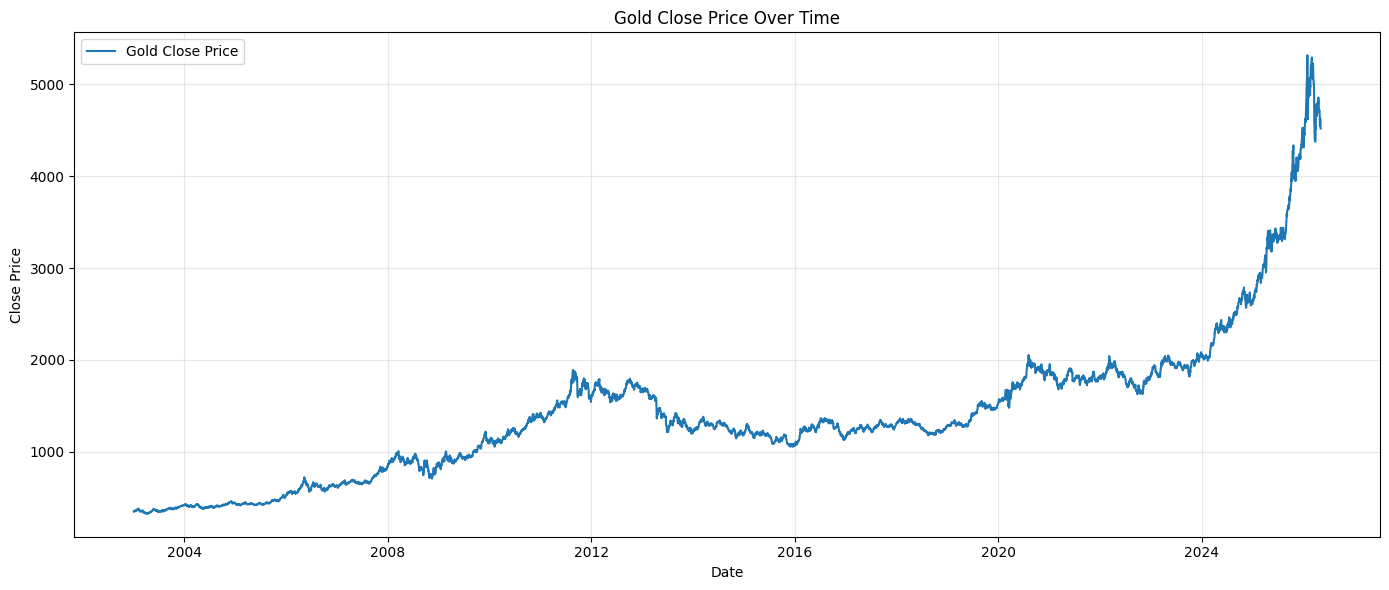

In [ ]:
plt.figure(figsize=(14, 6))                                    
plt.plot(df.index, df['close'], label="Gold Close Price") 
plt.title("Gold Close Price Over Time")                       
plt.xlabel("Date")                                             # Label the x-axis.
plt.ylabel("Close Price")                                      # Label the y-axis.
plt.legend()                                                    # Show the line label.
plt.grid(True, alpha=0.3)                                       
plt.tight_layout()                                             
plt.show()        

Insight: </br>
Berdasarkan line chart, harga penutupan emas menunjukkan tren kenaikan jangka panjang dari tahun 2003 hingga 2026. Pada awal periode, harga emas masih berada di sekitar 300-400 USD per troy ounce, kemudian meningkat secara bertahap dan mengalami beberapa fase kenaikan tajam, terutama setelah tahun 2008, sekitar tahun 2020, dan pada periode 2024-2026.

Grafik juga menunjukkan bahwa pergerakan harga emas tidak selalu stabil. Terdapat beberapa periode koreksi, seperti setelah kenaikan besar sekitar tahun 2011, sebelum harga kembali bergerak naik pada tahun-tahun berikutnya. Pola ini menunjukkan bahwa data harga emas memiliki tren yang kuat, tetapi tetap mengandung fluktuasi tinggi. Oleh karena itu, pendekatan time series seperti ARIMA, SARIMA, dan Prophet sesuai digunakan untuk menganalisis pola historis serta membangun model prediksi harga emas.


### Time Series Decomposition

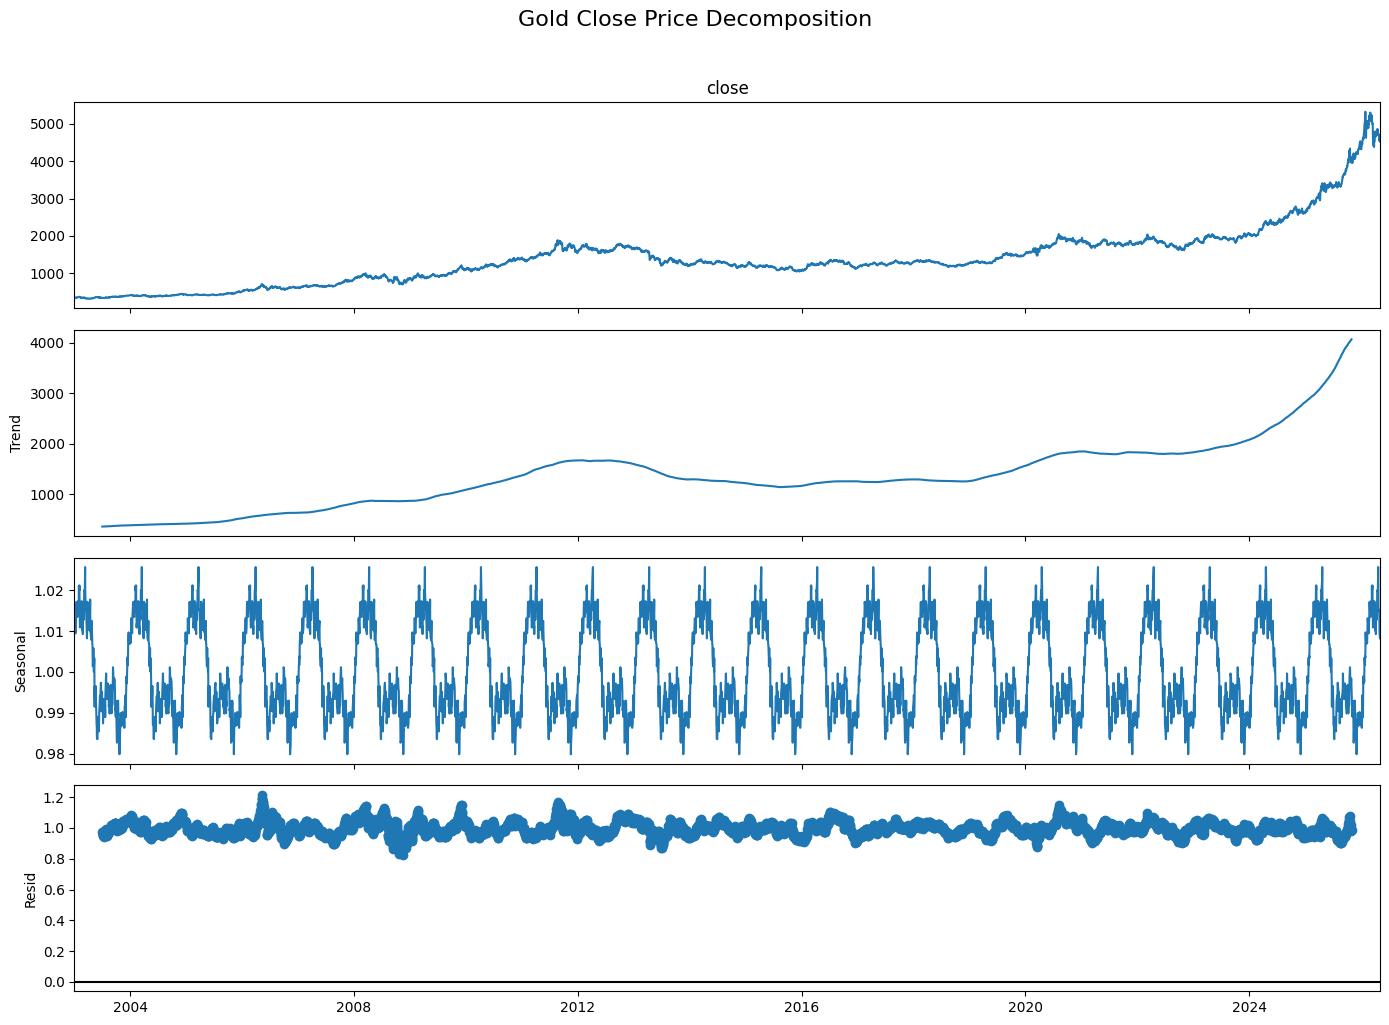

In [ ]:
DECOMPOSITION_PERIOD = 252                                     # Use 252 business days to approximate one trading year

decomposition = seasonal_decompose(                            
    df['close'],                                               
    model="multiplicative",                                    
    period=DECOMPOSITION_PERIOD                                
)                                                              
fig = decomposition.plot()                                     
fig.set_size_inches(14, 10)                                    
plt.suptitle("Gold Close Price Decomposition", y=1.02, fontsize=16) 
plt.tight_layout()                                            
plt.show()                                                     

Insight: </br>
Hasil time series decomposition menunjukkan bahwa pergerakan harga emas sangat dipengaruhi oleh komponen trend: 
- Pada bagian trend, terlihat kenaikan jangka panjang yang cukup jelas, terutama setelah tahun 2019 dan semakin tajam pada periode 2024-2026. Hal ini menunjukkan bahwa secara umum harga emas memiliki pola pertumbuhan yang kuat dalam jangka panjang, meskipun sempat mengalami penurunan atau perlambatan pada beberapa periode seperti setelah tahun 2011 hingga sekitar 2015.
- Komponen seasonal menunjukkan adanya pola musiman yang berulang secara konsisten, tetapi pengaruhnya relatif kecil dibandingkan trend utama. Nilai seasonal berada di sekitar 0.98 sampai 1.02, sehingga fluktuasi musiman hanya memberi variasi kecil terhadap harga emas. 
- Komponen residual menunjukkan adanya variasi acak atau noise yang tidak sepenuhnya dijelaskan oleh trend dan seasonality. Residual ini menandakan bahwa harga emas juga dipengaruhi oleh faktor lain di luar pola historis, seperti kondisi ekonomi global, sentimen pasar, inflasi, suku bunga, dan ketidakpastian geopolitik.


# 4. Data Preprocessing

In [ ]:
split_index = round(len(df) * 0.90)                 

train_series = df[:split_index].copy()                

test_series = df[split_index:].copy()                 

print("Total rows:", len(df))                              
print("Train rows:", len(train_series))                        
print("Test rows:", len(test_series))                          
print("Train date range:", train_series.index.min(), "to", train_series.index.max()) 
print("Test date range:", test_series.index.min(), "to", test_series.index.max()) 

Total rows: 5853
Train rows: 5268
Test rows: 585
Train date range: 2003-01-02 07:00:00+07:00 to 2024-01-04 07:00:00+07:00
Test date range: 2024-01-05 07:00:00+07:00 to 2026-05-04 07:00:00+07:00


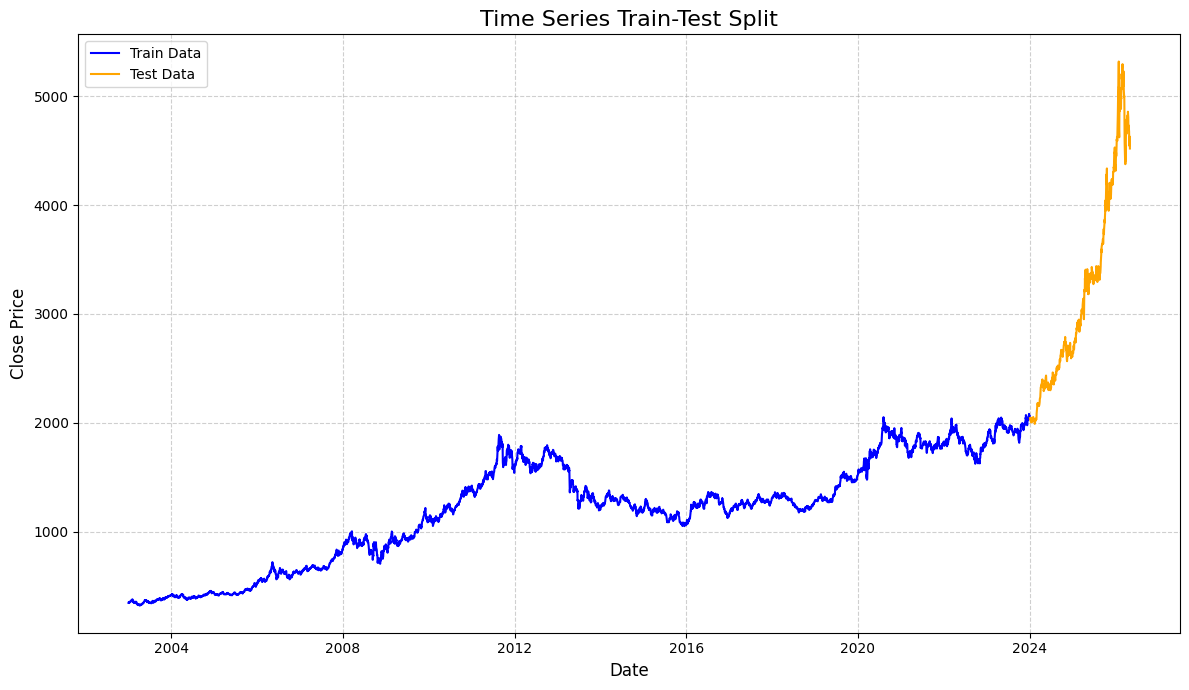

In [73]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(train_series.index, train_series['close'], color='blue', label='Train Data')
ax.plot(test_series.index, test_series['close'], color='orange', label='Test Data')
ax.set_title('Time Series Train-Test Split', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Close Price', fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Insight: </br>
Berikut line chart di atas menunjukan gambar visual untuk data train dan test. Dimana data train dimulai dari tahun 2003 sampai pertengahan 2024. Dan test dilakukan dari pertengahan 2024 sampai 2026 tanggal 4 Mei.

In [74]:
def perform_adf_test(series: pd.Series, series_name: str = "the series"):
    """
    Performs and prints the results of the Augmented Dickey-Fuller test.

    Args:
        series (pd.Series): The time series data to test.
        series_name (str): A descriptive name for the data being tested.
    """
    print(f"--- ADF Test Results for: {series_name} ---")

    # Perform the ADF test
    result = adfuller(series.dropna()) # dropna() is important for differenced series

    # Print the main results
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')

    # Print the conclusion
    print('\n--- Conclusion ---')
    if result[1] <= 0.05:
        print("The data is likely stationary.")
    else:
        print("The data is likely non-stationary.")
    print("-" * 40)

In [75]:
perform_adf_test(train_series['close'], series_name="Raw Training Data")

--- ADF Test Results for: Raw Training Data ---
ADF Statistic: -0.9612934139905731
p-value: 0.7671186611510636
Critical Values:
	1%: -3.431594767229596
	5%: -2.862090058410377
	10%: -2.567062795745212

--- Conclusion ---
The data is likely non-stationary.
----------------------------------------


In [ ]:
train_diff_1 = train_series.diff().dropna()                    

perform_adf_test(train_diff_1, "First-Differenced Gold Close Training Series") 

--- ADF Test Results for: First-Differenced Gold Close Training Series ---
ADF Statistic: -22.830770050273575
p-value: 0.0
Critical Values:
	1%: -3.431594767229596
	5%: -2.862090058410377
	10%: -2.567062795745212

--- Conclusion ---
The data is likely stationary.
----------------------------------------


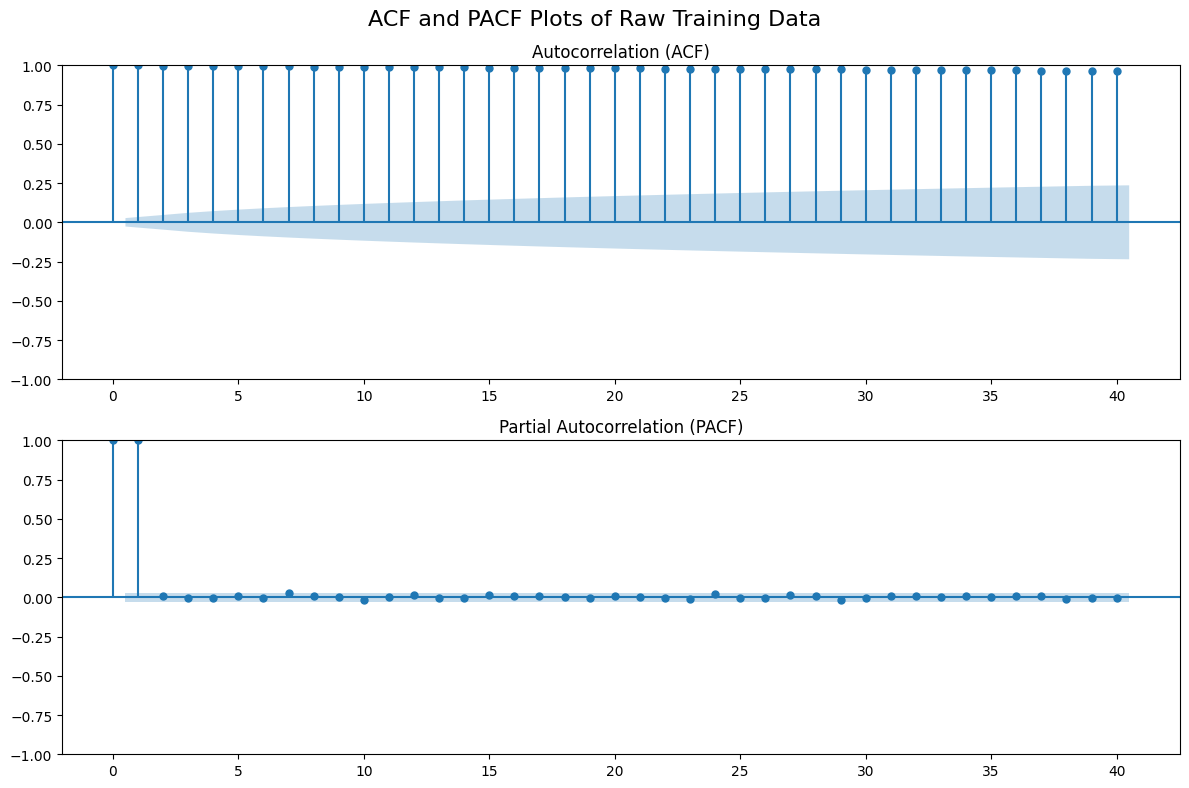

In [77]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle('ACF and PACF Plots of Raw Training Data', fontsize=16)
plot_acf(train_series['close'], ax=ax1, lags=40)
ax1.set_title('Autocorrelation (ACF)')
plot_pacf(train_series['close'], ax=ax2, lags=40)
ax2.set_title('Partial Autocorrelation (PACF)')
plt.tight_layout()
plt.show()

Insight: </br>
Berdasarkan plot ACF pada raw training data, nilai autocorrelation terlihat sangat tinggi menurun sangat lambat hingga lag ke-40 dan tidak ada cuts off terjadi. Pola ini menunjukkan bahwa harga emas saat ini masih memiliki hubungan yang kuat dengan harga pada periode-periode sebelumnya. Namun, karena korelasinya tidak cepat turun menuju nol, hal ini juga menjadi indikasi bahwa data raw masih mengandung trend dan belum stasioner.

Pada plot PACF, terlihat spike yang sangat kuat pada lag 1, sedangkan lag setelahnya cenderung kecil dan mengalami cuts off dan berada di sekitar batas confidence interval. Ini menunjukkan bahwa pengaruh terbesar terhadap harga emas saat ini berasal dari periode sebelumnya secara langsung. Kombinasi ACF yang menurun lambat dan hasil PACF yang dominan di lag awal mendukung hasil ADF test sebelumnya, yaitu raw training data masih bersifat non-stationary.

Oleh karena itu, data perlu dilakukan differencing sebelum digunakan pada model ARIMA/SARIMA. Proses differencing bertujuan untuk mengurangi trend dan membuat pola data menjadi lebih stasioner, sehingga model time series dapat menangkap struktur data dengan lebih baik.


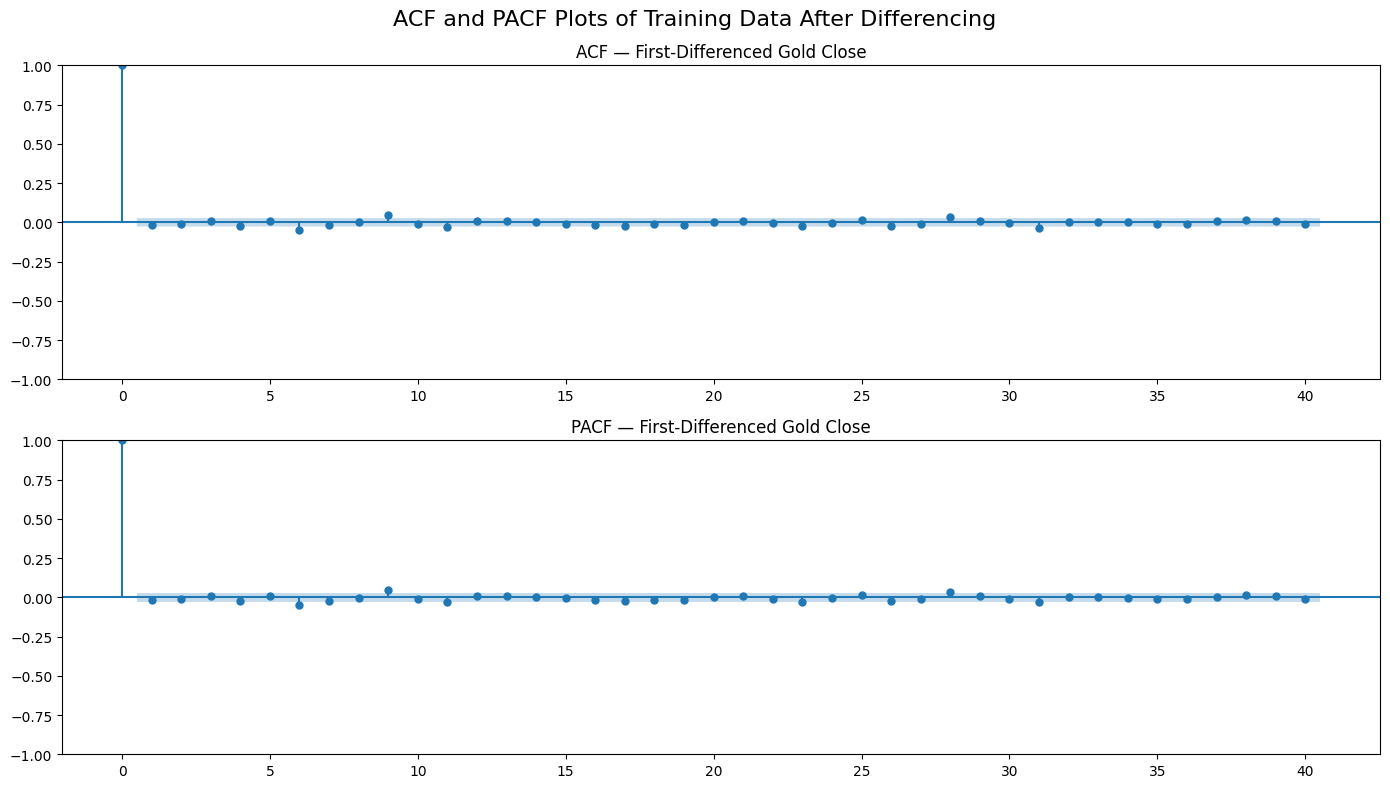

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))     
fig.suptitle('ACF and PACF Plots of Training Data After Differencing', fontsize=16)           
plot_acf(train_diff_1, ax=ax1, lags=40)                    
ax1.set_title("ACF — First-Differenced Gold Close")         
plot_pacf(train_diff_1, ax=ax2, lags=40, method="ywm")     
ax2.set_title("PACF — First-Differenced Gold Close")        
plt.tight_layout()                                             
plt.show()        

Insight: </br>
Setelah dilakukan first differencing: </br>
- Pola pada plot ACF berubah cukup signifikan dibandingkan data raw. Nilai autocorrelation pada sebagian besar lag sudah berada di sekitar nol dan berada dalam confidence interval. Hal ini menunjukkan bahwa proses differencing berhasil mengurangi efek trend pada data harga emas, sehingga data menjadi lebih stabil dan tidak lagi menunjukkan autocorrelation kuat yang menurun lambat seperti pada data raw.

- Plot PACF, sebagian besar nilai partial autocorrelation juga berada dekat dengan nol. Tidak terlihat spike besar yang dominan pada banyak lag, sehingga hubungan langsung antar periode setelah differencing menjadi jauh lebih lemah. Kondisi ini mendukung hasil ADF test sebelumnya, di mana data setelah differencing dinyatakan stasioner.

Secara keseluruhan, grafik ACF dan PACF setelah differencing menunjukkan bahwa penggunaan nilai `d = 1` pada model ARIMA/SARIMA sudah tepat. Karena tidak ada pola AR atau MA yang sangat kuat dan jelas, pemilihan parameter `p` dan `q` tetap perlu dibantu dengan proses pencarian model terbaik, seperti menggunakan AIC melalui grid search.


In [ ]:
def compute_forecast_metrics(y_true, y_pred, model_name):       
    y_true_array = np.asarray(y_true)                           
    y_pred_array = np.asarray(y_pred)                          
    mae = mean_absolute_error(y_true_array, y_pred_array)       
    rmse = np.sqrt(mean_squared_error(y_true_array, y_pred_array)) 
    mape = mean_absolute_percentage_error(y_true_array, y_pred_array) * 100 
    r2 = r2_score(y_true_array, y_pred_array)                   
    return {                                                    # Return all metrics as a dictionary.
        "Model": model_name,                                   # Store the model name.
        "MAE": mae,                                            # Store MAE.
        "RMSE": rmse,                                          # Store RMSE.
        "MAPE_%": mape,                                        # Store MAPE percentage.
        "R2": r2                                               # Store R2 score.
    }                                                          # End dictionary return.

# 4. Model Definition + Training + Evaluation

In [81]:
def find_best_arima(data: pd.Series, p_range, d_order, q_range):
    """
    Performs a grid search to find the best ARIMA(p,d,q) order.

    Args:
        data (pd.Series): The time series data.
        p_range (range): A range of values for the AR order 'p'.
        d_order (int): The fixed differencing order 'd'.
        q_range (range): A range of values for the MA order 'q'.
    """
    best_aic = float('inf')
    best_order = None
    results = []

    for p in p_range:
        for q in q_range:
            order = (p, d_order, q)
            try:
                model = ARIMA(data, order=order)
                result = model.fit()

                results.append({'Order': order, 'AIC': result.aic})

                if result.aic < best_aic:
                    best_aic = result.aic
                    best_order = order

            except Exception as e:
                continue
    results_df = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
    return results_df


In [87]:
p_values = range(0, 4)
d_values = 1
q_values = range(0, 4)

best_models_df = find_best_arima(train_series, p_values, d_values, q_values)
                # Print the best ARIMA order.
   
best_model = best_models_df.iloc[0]['Order']
print("Top 5 ARIMA Models by AIC:")
print("Best Arima: ", best_model)
print(best_models_df.head(10))

Top 5 ARIMA Models by AIC:
Best Arima:  (2, 1, 1)
       Order           AIC
0  (2, 1, 1)  42623.283734
1  (1, 1, 2)  42623.432522
2  (3, 1, 2)  42623.777797
3  (2, 1, 3)  42623.912089
4  (3, 1, 1)  42624.562325
5  (1, 1, 3)  42624.712815
6  (0, 1, 0)  42624.957356
7  (0, 1, 1)  42625.304659
8  (1, 1, 0)  42625.336769
9  (2, 1, 0)  42626.805021


Insight: </br>
Dari hasil Grid Search untuk menemukan parameter terbaik untuk model ARIMA, didapatkan order dengan parameter (2, 1, 1) adalah yang terbaik dengan nilai AIC tertinggi 42623.28. Maka dari itu parameter ini akan digunakan untuk model training, testing dan forecasting nanti.

In [ ]:
arima_model = ARIMA(train_series, order=best_model)       # Define final ARIMA model using the best order from grid search.
arima_result = arima_model.fit()                                # Fit the final ARIMA model.

print(arima_result.summary())              

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 5268
Model:                 ARIMA(2, 1, 1)   Log Likelihood              -21307.642
Date:                Wed, 06 May 2026   AIC                          42623.284
Time:                        16:49:32   BIC                          42649.561
Sample:                             0   HQIC                         42632.469
                               - 5268                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8478      0.102     -8.319      0.000      -1.047      -0.648
ar.L2         -0.0334      0.010     -3.472      0.001      -0.052      -0.015
ma.L1          0.8309      0.101      8.255      0.0

In [97]:
train_predictions_arima = arima_result.predict(start=train_series.index[0], end=train_series.index[-1]) # Generate ARIMA predictions for the test period.

In [98]:
pred_train = pd.DataFrame(train_predictions_arima, index=train_series.index)
pred_train

,predicted_mean
date,
2003-01-02 07:00:00+07:00,0.000000
2003-01-03 07:00:00+07:00,346.098845
2003-01-06 07:00:00+07:00,351.109345
2003-01-07 07:00:00+07:00,351.595818
2003-01-08 07:00:00+07:00,347.447071
...,...
2023-12-28 07:00:00+07:00,2081.816362
2023-12-29 07:00:00+07:00,2073.312232
2024-01-02 07:00:00+07:00,2063.350093


In [99]:
train_concat = pd.concat([train_series, pred_train], axis=1)
train_concat

,close,predicted_mean
date,,
2003-01-02 07:00:00+07:00,346.100006,0.000000
2003-01-03 07:00:00+07:00,351.200012,346.098845
2003-01-06 07:00:00+07:00,351.700012,351.109345
2003-01-07 07:00:00+07:00,347.299988,351.595818
2003-01-08 07:00:00+07:00,353.899994,347.447071
...,...,...
2023-12-28 07:00:00+07:00,2073.899902,2081.816362
2023-12-29 07:00:00+07:00,2062.399902,2073.312232
2024-01-02 07:00:00+07:00,2064.399902,2063.350093


In [103]:
test_predictions = arima_result.forecast(steps=len(test_series))

In [ ]:
pred_test = test_predictions.rename("predicted_mean").to_frame()
pred_test.head()

,predicted_mean
5268,2042.501092
5269,2042.059846
5270,2042.427197
5271,2042.130522
5272,2042.369751


In [108]:
pred_test.index = test_series.index
pred_test.head()

,predicted_mean
date,
2024-01-05 07:00:00+07:00,2042.501092
2024-01-08 07:00:00+07:00,2042.059846
2024-01-09 07:00:00+07:00,2042.427197
2024-01-10 07:00:00+07:00,2042.130522
2024-01-11 07:00:00+07:00,2042.369751


In [109]:
test_concat = pd.concat([test_series[["close"]], pred_test], axis=1)
test_concat

,close,predicted_mean
date,,
2024-01-05 07:00:00+07:00,2042.400024,2042.501092
2024-01-08 07:00:00+07:00,2026.599976,2042.059846
2024-01-09 07:00:00+07:00,2026.400024,2042.427197
2024-01-10 07:00:00+07:00,2021.699951,2042.130522
2024-01-11 07:00:00+07:00,2014.300049,2042.369751
...,...,...
2026-04-28 07:00:00+07:00,4591.500000,2042.262963
2026-04-29 07:00:00+07:00,4545.200195,2042.262963
2026-04-30 07:00:00+07:00,4614.700195,2042.262963


In [111]:
mae_train = mean_absolute_error(train_series, train_predictions_arima)
mae_test = mean_absolute_error(test_series, test_predictions)
print(f"Train MAE: {mae_train:.4f}")
print(f"Test MAE:  {mae_test:.4f}")

Train MAE: 9.2596
Test MAE:  1156.3710


In [ ]:
arima_forecast_object = arima_result.get_forecast(steps=len(test_series)) 
arima_test_pred = arima_forecast_object.predicted_mean          
arima_conf_int = arima_forecast_object.conf_int()               
arima_test_pred.index = test_series.index                       
arima_conf_int.index = test_series.index                        

arima_metrics = compute_forecast_metrics(                      
    y_true=test_series,                                        
    y_pred=arima_test_pred,                                     
    model_name=f"ARIMA{best_model}"                      
)                                                              

arima_metrics   

{'Model': 'ARIMA(2, 1, 1)',
 'MAE': 1156.3710179821708,
 'RMSE': 1463.605573608084,
 'MAPE_%': 31.373866018529128,
 'R2': -1.6436154155940343}

### SARIMA

In [ ]:
def find_best_sarima_order(train_data, order_list, seasonal_order_list): 
    results = []                                               
    best_aic = np.inf                                           
    best_order = None                                           
    best_seasonal_order = None                                 
    for order in order_list:                                    
        for seasonal_order in seasonal_order_list:             
            try:                                                
                model = sm.tsa.statespace.SARIMAX(             
                    train_data,                                 
                    order=order,                                
                    seasonal_order=seasonal_order,              
                    enforce_stationarity=False,                
                    enforce_invertibility=False                 
                )                                              
                fitted_model = model.fit(disp=False)            
                aic = fitted_model.aic                          
                results.append({                                
                    "order": order,                           
                    "seasonal_order": seasonal_order,          
                    "AIC": aic                                
                })                                             
                if aic < best_aic:                             
                    best_aic = aic                             
                    best_order = order                          
                    best_seasonal_order = seasonal_order        
            except Exception as error:                          
                continue                                        
    results_df = pd.DataFrame(results)                          
    results_df = results_df.sort_values("AIC").reset_index(drop=True) # Sort from best AIC to worst AIC.
    return best_order, best_seasonal_order, results_df 

In [ ]:
p = range(0, 3)                                                
d = [1]                                                        
q = range(0, 3)                                                 
P = range(0, 2)                                                
D = [0, 1]                                                     
Q = range(0, 2)                                                 
m = 5                                                        

order_list = list(itertools.product(p, d, q))                  

seasonal_order_list = [(x[0], x[1], x[2], m) for x in itertools.product(P, D, Q)] 

print("Number of SARIMA combinations:", len(order_list) * len(seasonal_order_list)) 

Number of SARIMA combinations: 72


In [ ]:
best_sarima_order, best_sarima_seasonal_order, sarima_search_results = find_best_sarima_order( 
    train_data=train_series,                                   
    order_list=order_list,                                     
    seasonal_order_list=seasonal_order_list                    
)                                                             

print("Best SARIMA order:", best_sarima_order)                 
print("Best SARIMA seasonal order:", best_sarima_seasonal_order) 

display(sarima_search_results.head(10))                        

Best SARIMA order: (0, 1, 2)
Best SARIMA seasonal order: (0, 1, 1, 5)


,order,seasonal_order,AIC
0,"(0, 1, 2)","(0, 1, 1, 5)",42561.589482
1,"(1, 1, 2)","(0, 1, 1, 5)",42562.180833
2,"(1, 1, 2)","(1, 1, 1, 5)",42562.950087
3,"(0, 1, 2)","(1, 1, 1, 5)",42563.399150
4,"(2, 1, 2)","(0, 1, 1, 5)",42563.661230
5,"(2, 1, 2)","(1, 1, 1, 5)",42565.841872
6,"(0, 1, 1)","(0, 1, 1, 5)",42567.341952
7,"(1, 1, 1)","(0, 1, 1, 5)",42568.732777
8,"(1, 1, 2)","(0, 0, 1, 5)",42568.782405
9,"(2, 1, 1)","(0, 1, 1, 5)",42568.805039


Insight: </br>
Dari hasil Grid Search untuk menemukan parameter terbaik untuk model ARIMA, didapatkan order dengan parameter (2, 1, 1) adalah yang terbaik dengan nilai AIC tertinggi 42623.28. Maka dari itu parameter ini akan digunakan untuk model training, testing dan forecasting nanti.

In [ ]:
sarima_model = sm.tsa.statespace.SARIMAX(                      
    train_series,                                               # Use training series.
    order=best_sarima_order,                                    # Use best non-seasonal order.
    seasonal_order=best_sarima_seasonal_order,                  # Use best seasonal order.
    enforce_stationarity=False,                                 # Relax stationarity enforcement.
    enforce_invertibility=False                                 # Relax invertibility enforcement.
)                                                              # End SARIMAX definition.

sarima_result = sarima_model.fit(disp=False)                   # Fit final SARIMA model quietly.

print(sarima_result.summary())  

                                      SARIMAX Results                                      
Dep. Variable:                               close   No. Observations:                 5268
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 5)   Log Likelihood              -21276.795
Date:                             Wed, 06 May 2026   AIC                          42561.589
Time:                                     17:39:40   BIC                          42587.856
Sample:                                          0   HQIC                         42570.773
                                            - 5268                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0178      0.009     -1.958      0.050      -0.036    1.58e-05
ma.L2         -0.0104      

In [132]:
train_predictions_sarima = sarima_result.predict(start=train_series.index[0], end=train_series.index[-1]) # Generate SARIMA predictions for the training period.
pred_train_sarima = pd.DataFrame(train_predictions_sarima, index=train_series.index)
pred_train_sarima

,predicted_mean
date,
2003-01-02 07:00:00+07:00,0.000000
2003-01-03 07:00:00+07:00,346.100006
2003-01-06 07:00:00+07:00,351.200003
2003-01-07 07:00:00+07:00,351.700006
2003-01-08 07:00:00+07:00,347.299995
...,...
2023-12-28 07:00:00+07:00,2082.166358
2023-12-29 07:00:00+07:00,2074.032899
2024-01-02 07:00:00+07:00,2063.218703


In [133]:
train_concat_sarima = pd.concat([train_series, pred_train_sarima], axis=1)
train_concat_sarima

,close,predicted_mean
date,,
2003-01-02 07:00:00+07:00,346.100006,0.000000
2003-01-03 07:00:00+07:00,351.200012,346.100006
2003-01-06 07:00:00+07:00,351.700012,351.200003
2003-01-07 07:00:00+07:00,347.299988,351.700006
2003-01-08 07:00:00+07:00,353.899994,347.299995
...,...,...
2023-12-28 07:00:00+07:00,2073.899902,2082.166358
2023-12-29 07:00:00+07:00,2062.399902,2074.032899
2024-01-02 07:00:00+07:00,2064.399902,2063.218703


In [134]:
test_predictions_sarima = sarima_result.forecast(steps=len(test_series))
pred_test_sarima = test_predictions_sarima.rename("predicted_mean").to_frame()
pred_test_sarima.head()

,predicted_mean
5268,2043.176365
5269,2043.316701
5270,2043.844289
5271,2043.537135
5272,2044.036107


In [135]:
pred_test_sarima.index = test_series.index
pred_test_sarima.head()

,predicted_mean
date,
2024-01-05 07:00:00+07:00,2043.176365
2024-01-08 07:00:00+07:00,2043.316701
2024-01-09 07:00:00+07:00,2043.844289
2024-01-10 07:00:00+07:00,2043.537135
2024-01-11 07:00:00+07:00,2044.036107


In [136]:
test_concat_sarima = pd.concat([test_series[["close"]], pred_test_sarima], axis=1)
test_concat_sarima

,close,predicted_mean
date,,
2024-01-05 07:00:00+07:00,2042.400024,2043.176365
2024-01-08 07:00:00+07:00,2026.599976,2043.316701
2024-01-09 07:00:00+07:00,2026.400024,2043.844289
2024-01-10 07:00:00+07:00,2021.699951,2043.537135
2024-01-11 07:00:00+07:00,2014.300049,2044.036107
...,...,...
2026-04-28 07:00:00+07:00,4591.500000,2231.589149
2026-04-29 07:00:00+07:00,4545.200195,2231.802823
2026-04-30 07:00:00+07:00,4614.700195,2232.330411


In [157]:
mae_train_sarima = mean_absolute_error(train_series, train_predictions_sarima)
mae_test_sarima = mean_absolute_error(test_series, test_predictions_sarima)
print(f"Train MAE: {mae_train_sarima:.4f}")
print(f"Test MAE:  {mae_test_sarima:.4f}")

Train MAE: 9.3157
Test MAE:  1061.6288


In [ ]:
sarima_forecast_object = sarima_result.get_forecast(steps=len(test_series)) 
sarima_test_pred = sarima_forecast_object.predicted_mean        
sarima_conf_int = sarima_forecast_object.conf_int()             
sarima_test_pred.index = test_series.index                      
sarima_conf_int.index = test_series.index                       
sarima_metrics = compute_forecast_metrics(                      
    y_true=test_series,                                         
    y_pred=sarima_test_pred,                                    
    model_name=f"SARIMA{best_sarima_order}x{best_sarima_seasonal_order}"
)                                                             

sarima_metrics  

{'Model': 'SARIMA(0, 1, 2)x(0, 1, 1, 5)',
 'MAE': 1061.628821111754,
 'RMSE': 1356.1491846743006,
 'MAPE_%': 28.66980575509695,
 'R2': -1.269682456265878}

### Prophet

In [ ]:
prophet_df = df.reset_index()                              

prophet_df.columns = ["ds", "y"]                               

prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])           
prophet_df["ds"] = prophet_df["ds"].dt.tz_localize(None)      
prophet_train = prophet_df.iloc[:split_index].copy()            # Use the same training period as ARIMA/SARIMA.

prophet_test = prophet_df.iloc[split_index:].copy()             # Use the same test period as ARIMA/SARIMA.

prophet_train.head()                                           # Show first rows of Prophet training data.                                      # Show first rows of Prophet training data.

,ds,y
0,2003-01-02 07:00:00,346.100006
1,2003-01-03 07:00:00,351.200012
2,2003-01-06 07:00:00,351.700012
3,2003-01-07 07:00:00,347.299988
4,2003-01-08 07:00:00,353.899994


In [ ]:
prophet_model = Prophet(                                   
        growth="linear",                                      
        yearly_seasonality=True,                               
        weekly_seasonality=True,                              
        daily_seasonality=False,                               
        seasonality_mode="multiplicative",                     
        changepoint_prior_scale=0.05                            
        )                                                       
prophet_model.fit(prophet_train)                            # Fit Prophet on training data.


17:59:28 - cmdstanpy - INFO - Chain [1] start processing
17:59:38 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
prophet_future = prophet_test[["ds"]].copy()               
prophet_forecast = prophet_model.predict(prophet_future)   
prophet_test_pred = prophet_forecast["yhat"].copy()       
prophet_test_pred.index = test_series.index                 
prophet_metrics = compute_forecast_metrics(                 
        y_true=test_series,                                     
        y_pred=prophet_test_pred,                               
        model_name="Prophet"       )

prophet_metrics

{'Model': 'Prophet',
 'MAE': 1136.6036231861478,
 'RMSE': 1419.4134021610987,
 'MAPE_%': 31.107361325829487,
 'R2': -1.4863826660587693}

### Metrics Comparison ARIMA vs SARIMA vs PROPHET

In [150]:
all_metrics = [arima_metrics, sarima_metrics, prophet_metrics] # Combine all model metrics into a list.
comparison_df = pd.DataFrame(all_metrics)   
comparison_df = comparison_df.sort_values("RMSE").reset_index(drop=True)
comparison_df 

,Model,MAE,RMSE,MAPE_%,R2
0,"SARIMA(0, 1, 2)x(0, 1, 1, 5)",1061.628821,1356.149185,28.669806,-1.269682
1,Prophet,1136.603623,1419.413402,31.107361,-1.486383
2,"ARIMA(2, 1, 1)",1156.371018,1463.605574,31.373866,-1.643615


Insight: </br>
Dari hasil predict ke data test untuk ARIMA, SARIMA dan Prophet menunjukan SARIMA menghasilkan score predict terbaik dimana RMSE dan MAE terendah dari semua model dan R2 nya juga mendapatkan score terbaik

In [152]:
best_model_name = comparison_df.iloc[0]["Model"]              
print("Best model based on test RMSE:", best_model_name)  

Best model based on test RMSE: SARIMA(0, 1, 2)x(0, 1, 1, 5)


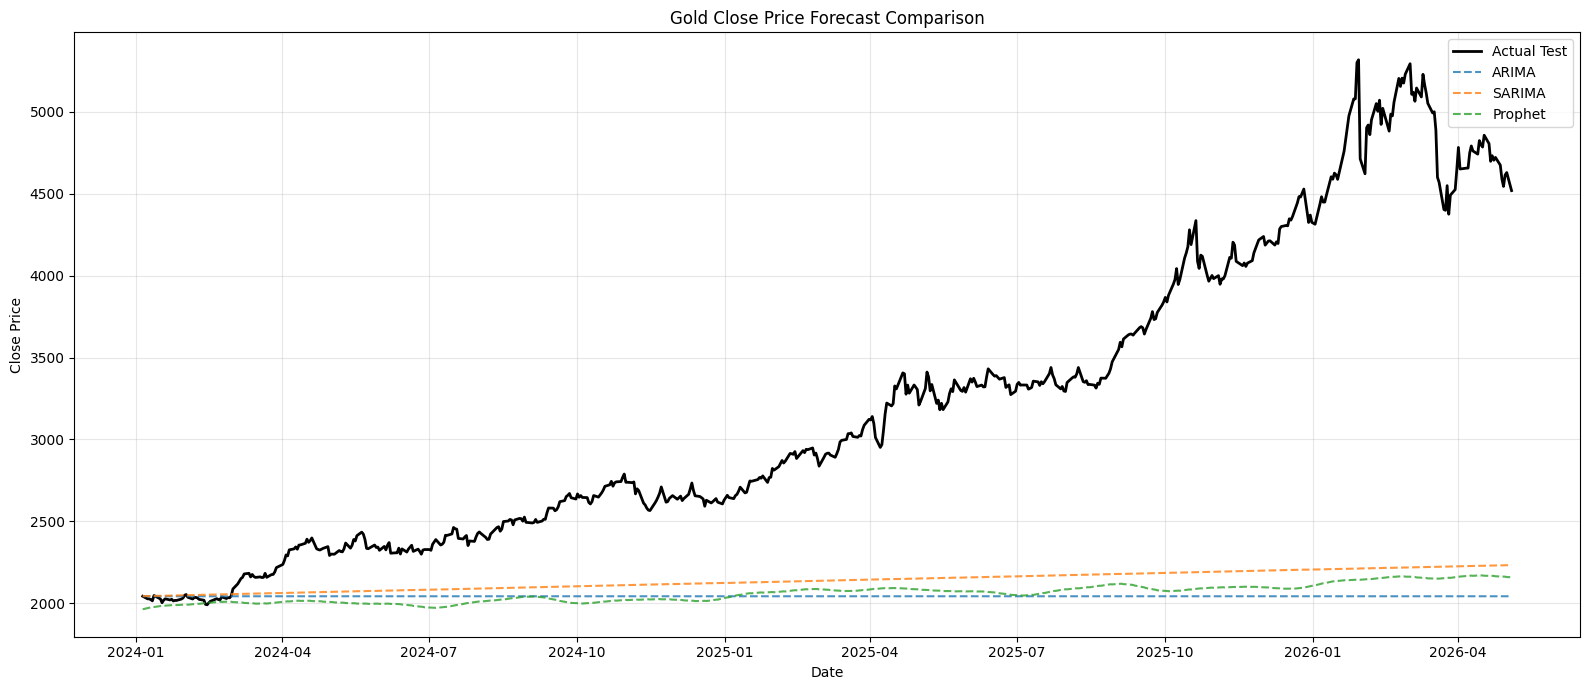

In [ ]:
# ============================================================  # Section separator.
# FINAL FORECAST COMPARISON PLOT                               
# ============================================================  # Section separator.

plt.figure(figsize=(16, 7))                                    # Create a wide figure.
plt.plot(test_series.index, test_series, label="Actual Test", color="black", linewidth=2) 
plt.plot(test_series.index, arima_test_pred, label="ARIMA", linestyle="--", alpha=0.8) 
plt.plot(test_series.index, sarima_test_pred, label="SARIMA", linestyle="--", alpha=0.8) 
plt.plot(test_series.index, prophet_test_pred, label="Prophet", linestyle="--", alpha=0.8) 
plt.title("Gold Close Price Forecast Comparison")               
plt.xlabel("Date")                                             # Label x-axis.
plt.ylabel("Close Price")                                      # Label y-axis.
plt.legend()                                                   
plt.grid(True, alpha=0.3)                                       
plt.tight_layout()                                              # Adjust layout.
plt.show()                                                      # Display chart.

Insight Final Forecast: </br>
- Berdasarkan grafik final forecast comparison, terlihat bahwa seluruh model belum mampu mengikuti kenaikan harga emas yang sangat tajam pada periode data test. Actual price mengalami lonjakan besar dari sekitar awal 2024 hingga 2026, sedangkan hasil forecast dari ARIMA, SARIMA, dan Prophet cenderung lebih datar dan bergerak jauh di bawah nilai aktual. Hal ini membuat nilai evaluasi seperti MAE, RMSE, MAPE, dan R2 terlihat kurang baik.

- Namun, hasil ini tidak langsung berarti model sepenuhnya gagal. Evaluasi pada bagian ini dilakukan dengan memprediksi seluruh periode test sekaligus dalam horizon yang cukup panjang. Karena model hanya dilatih menggunakan data train, model tidak mendapatkan update dari pergerakan terbaru selama periode test. Akibatnya, ketika terjadi perubahan trend yang sangat kuat pada harga emas, error menjadi semakin besar seiring bertambahnya panjang periode forecast.

- Dari hasil perbandingan metrik: 
- SARIMA tetap menjadi model terbaik dibandingkan ARIMA dan Prophet karena memiliki nilai RMSE dan MAE paling rendah, serta R2 yang paling baik di antara ketiga model. Parameter terbaik yang diperoleh adalah SARIMA(0, 1, 2)x(0, 1, 1, 5). Oleh karena itu, model dan parameter ini dapat digunakan sebagai model final, tetapi sebelum digunakan untuk inference, model perlu di-refit menggunakan seluruh data historis agar prediksi berikutnya memanfaatkan informasi terbaru.




### Refit Best Model

In [ ]:
#Refit Best Model ke Full Dataset
best_sarima_order = (0, 1, 2)
best_sarima_seasonal_order = (0, 1, 1, 5)

full_close_series = df["close"].copy()
full_close_series = full_close_series.sort_index()
final_sarima_model = sm.tsa.statespace.SARIMAX(
    full_close_series,
    order=best_sarima_order,
    seasonal_order=best_sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Fit final model.
final_sarima_result = final_sarima_model.fit(disp=False)
print(final_sarima_result.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               close   No. Observations:                 5853
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 5)   Log Likelihood              -26316.785
Date:                             Thu, 07 May 2026   AIC                          52641.570
Time:                                     00:28:09   BIC                          52668.259
Sample:                                          0   HQIC                         52650.851
                                            - 5853                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0356      0.004     -8.550      0.000      -0.044      -0.027
ma.L2         -0.0661      

In [169]:
forecast_object_next_day = final_sarima_result.get_forecast(steps=1)
forecast_next_day_troy_usd = forecast_object_next_day.predicted_mean.iloc[0]
print(f"Forecasted Gold Close Price for Next Day: ${forecast_next_day_troy_usd:.2f} per troy ounce")

Forecasted Gold Close Price for Next Day: $4523.43 per troy ounce


# 7. Model Saving

In [ ]:
# Save the final refitted SARIMA model.
# Final Model for inference
final_sarima_result.save("models/sarima_final_model.pkl")
print("Final SARIMA model saved to: models/sarima_final_model.pkl")


Final SARIMA model saved to: models/sarima_final_model.pkl


# 8. Model Inference

Di Notebook satu lagi

# 9. Conclusion



- Project ini berhasil membangun model prediksi harga emas berbasis time series menggunakan data historis harga emas dari tahun 2003 hingga 2026.

- Berdasarkan hasil eksplorasi data, harga emas menunjukkan tren kenaikan jangka panjang, terutama pada periode setelah 2020 dan semakin meningkat tajam pada 2024-2026.

- Hasil time series decomposition menunjukkan bahwa pergerakan harga emas lebih banyak dipengaruhi oleh komponen trend, sedangkan pola seasonal ada tetapi pengaruhnya relatif kecil dibandingkan trend utama.

- Berdasarkan ADF test, data raw harga emas bersifat non-stationary. Setelah dilakukan first differencing, data menjadi stationary, sehingga penggunaan nilai `d = 1` pada model ARIMA dan SARIMA sudah sesuai.

- Model yang dibandingkan dalam project ini adalah ARIMA, SARIMA, dan Prophet. Dari hasil evaluasi, SARIMA menjadi model terbaik karena memiliki nilai error paling rendah dibandingkan model lainnya.

- Model terbaik yang diperoleh adalah `SARIMA(0, 1, 2)x(0, 1, 1, 5)` dengan nilai MAE sebesar `1061.63`, RMSE sebesar `1356.15`, dan MAPE sebesar `28.67%`.

- Meskipun SARIMA menjadi model terbaik, nilai evaluasi pada data test masih belum ideal. Hal ini terjadi karena periode test memiliki kenaikan harga emas yang sangat tajam, sedangkan forecast dilakukan untuk horizon yang cukup panjang tanpa melakukan update model selama periode test.

- Oleh karena itu, model terbaik kemudian di-refit menggunakan seluruh data historis agar dapat memanfaatkan informasi terbaru sebelum digunakan untuk inference.

- Secara keseluruhan, SARIMA dapat digunakan sebagai model final untuk prediksi harga emas jangka pendek, tetapi hasil prediksi tetap perlu digunakan sebagai alat bantu analisis, bukan sebagai satu-satunya dasar pengambilan keputusan trading atau investasi.


# Business Impact:
1. Mendukung pengambilan keputusan investasi/trading karena sistem forecasting akan membantu user mendapatkan gambaran estimasi harga emas untuk hari berikutnya dan beberapa hari kedepan.
2. Meningkatkan efisiensi analisis pasar karena user tidak perlu analisas lagi seluruh data historis secara manual karena model sudah mempelajari pola pergerakan harga emas.
3. Membantu manajemen risiko karena prediksi harga dapat digunakan sebagai referensi awal untuk antisipasi potensi kenaikan atau penurunan sehingga user dapat mentusun strategi beli emas.
